# Photon Subtraction in Graph State
2026\. 05\. 21.  Test the other case

In [1]:
def triangular_lattice_adjacency(n_rows):
    """
    Triangular lattice graph.

    n_rows:
        number of rows.
        total node number = n_rows * (n_rows + 1) / 2

    Node coordinate:
        (r, c), where r = row index, c = position in row.
    """

    idx = {}
    node = 0

    for r in range(n_rows):
        for c in range(r + 1):
            idx[(r, c)] = node
            node += 1

    m = node
    Adj = np.zeros((m, m))

    def add_edge(a, b):
        i, j = idx[a], idx[b]
        Adj[i, j] = 1
        Adj[j, i] = 1

    for r in range(n_rows):
        for c in range(r + 1):

            # horizontal edge
            if c < r:
                add_edge((r, c), (r, c + 1))

            # downward edges
            if r < n_rows - 1:
                add_edge((r, c), (r + 1, c))
                add_edge((r, c), (r + 1, c + 1))

    # nice triangular layout
    pos = {}
    for (r, c), i in idx.items():
        x = c - r / 2
        y = -np.sqrt(3) / 2 * r
        pos[i] = (x, y)

    return Adj, pos, idx

## 1. Set the graph state

##### Initial parameters, modules and functions

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
# Graph: paper-style 6-node graph, labels 1-6 1-2-(3,4)-5-6 graph

# Adj = np.array([[0, 1, 0, 0, 0, 0],
#                 [1, 0, 1, 1, 0, 0],
#                 [0, 1, 0, 0, 1, 0],
#                 [0, 1, 0, 0, 1, 0],
#                 [0, 0, 1, 1, 0, 1],
#                 [0, 0, 0, 0, 1, 0]], dtype=float)



n_rows = 12
Adj, pos, idx = triangular_lattice_adjacency(n_rows)
m = Adj.shape[0]

# visual center-ish node
r = n_rows // 2
c = r // 2
center_idx = idx[(r, c)]

print("center node =", center_idx + 1)
print("row, col =", r, c)


# Phase-space convention: q = (x1, ..., xm, p1, ..., pm)
I_m = np.eye(m)
Z_m = np.zeros((m, m))
Omega = np.block([[Z_m, I_m], [-I_m, Z_m]]) # [0, I; -I, 0] symplectic form
J = Omega.T # [0, -I; I, 0] symplectic form in Mattia's convention

# CZ symplectic matrix
G = np.block([[I_m, Z_m], [Adj, I_m]])

# Input covariance, paper convention: vacuum variance = 1
squeezing_db = np.full(m, 10, dtype=float) # 단위는 dB 
#squeezing_db = np.array([3, 4, 12, 5, 3, 5], dtype=float) # mode별로 squeezing 다르게 주는 경우

s = 10 ** (squeezing_db / 10) # 단위 변환
V0 = np.diag(np.concatenate([s, 1 / s])) # diag(s_1, ..., s_m, 1/s_1, ..., 1/s_m)


# Graph-state covariance
V = G @ V0 @ G.T # maybe later we adjust this code to general mixed case.

# Photon-subtraction mode
# annhilation operator 기준으로 photon subtraction을 설명하기 위한 f이다. 복소수가 가능하며 C^(m)이다.
# a(f) = f1 a1 + f2 a2 + ... + fm am 이다.

#f_sub = np.array([1, 0, 0, 0, 0, 0], dtype=complex) # a(f_sub) = sum f_sub[i] a_i
f_sub = np.zeros(m, dtype=complex)
f_sub[center_idx] = 1.0

f_sub = f_sub / np.linalg.norm(f_sub) # 정규화


# mattia convention으로 표현, g_sub이 전부 실수 R^(2m)이다. -> 이는 quadrature 기준으로 중첩을 설명하기 위한 convention이다.
# 수식적으로는 g = (Re(f), -Im(f))^T)이고, Q(g) = x(g), Q(Jg) = p(g)이다.

g_sub = np.concatenate([np.real(f_sub), -np.imag(f_sub)]) # g_sub = (Re(f_sub), -Im(f_sub)) in phase space , a(f_sub) = 1/2 (Q(g_sub)+iQ(Jg_sub)) 
Jg_sub = J @ g_sub
Pi_g = np.outer(g_sub, g_sub) + np.outer(Jg_sub, Jg_sub) # Πg =ggT + Jg(Jg)T , projection matrix for the subtracted mode


sub_label = f"center mode {center_idx + 1}"

center node = 25
row, col = 6 3


###### graph plotting function

In [3]:
from matplotlib.colors import LinearSegmentedColormap
from cmcrameri import cm

blue = LinearSegmentedColormap.from_list(
    "blue",
    ["#3f5f87", "#7b8a70", "#fffbe6"]
)

red = LinearSegmentedColormap.from_list(
    "red",
    ["#18051f", "#5b2a86", "#d44a1c", "#ffc247", "#fffbe6"]
)

In [4]:
def plot_graph_from_matrix(
    W,
    node_values=None,
    title="",
    threshold=1e-6,
    pos=None,
    cmap=blue,
    vmin=None,
    vmax=None,
    colorbar_label="",
    draw_labels=True,
    colorbar_extend="neither"
):
    """
    W: weighted adjacency matrix 
    node_values: optional node color values, e.g. kurtosis, purity, nullifier_var
    """

    W_plot = np.array(W, dtype=float).copy()
    G_plot = nx.from_numpy_array(W_plot)

    # automatic layout - 어느정도 정렬된 그래프를 그려준다. 더 깔끔하게 그리고 싶을때는 pos를 직접 지정
    if pos is None:
        pos = nx.kamada_kawai_layout(G_plot)

    # node label을 1부터 시작하게 바꿈
    labels = {i: i + 1 for i in range(W_plot.shape[0])}

    # node_values가 있으면 논문 figure처럼 label을 기본적으로 끔
    if draw_labels is None:
        draw_labels = node_values is None



    n_nodes = W_plot.shape[0]

    if n_nodes <= 10:
        fig_size = (4.2, 3.2)
        node_size = 700
        font_size = 9
        edge_width = 1.4
    elif n_nodes <= 80:
        fig_size = (6.2, 5.4)
        node_size = 150
        font_size = 5
        edge_width = 0.8
    else:
        fig_size = (7.0, 6.0)
        node_size = 80
        font_size = 4
        edge_width = 0.5


    # plotting // 사이즈 설정
    plt.figure(figsize=fig_size, dpi=180)


    
    
    # graph edge(선) 그리기
    nx.draw_networkx_edges(
        G_plot,
        pos,
        edge_color="#5b668a",
        width=edge_width,
        alpha=0.75
    )

    # graph node(노드) 그리기
    if node_values is None:
        nx.draw_networkx_nodes(
            G_plot,
            pos,
            node_color="white",
            edgecolors="black",
            linewidths=1.1,
            node_size=node_size
        )

    else:
        node_values_plot = np.asarray(node_values, dtype=float)

        # colorbar range를 node_values에서 자동 설정
        if vmin is None:
            vmin = np.nanmin(node_values_plot)
        if vmax is None:
            vmax = np.nanmax(node_values_plot)

        # 모든 node value가 같은 경우 colorbar error 방지
        if np.isclose(vmin, vmax):
            vmin -= 1e-9
            vmax += 1e-9

        nodes = nx.draw_networkx_nodes(
            G_plot,
            pos,
            node_color=node_values_plot,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolors="#444444",
            linewidths=1.1,
            node_size=node_size
        )


        cbar = plt.colorbar(nodes, fraction=0.045, pad=0.03, extend=colorbar_extend)

        if colorbar_label:
            cbar.set_label(colorbar_label, fontsize=9)

        cbar.ax.tick_params(labelsize=8)

        if colorbar_extend == "min" and vmin is not None and vmax is not None:
            ticks = cbar.get_ticks()
            ticks = ticks[(ticks >= vmin) & (ticks <= vmax)]

            if not np.any(np.isclose(ticks, vmin)):
                ticks = np.insert(ticks, 0, vmin)

            cbar.set_ticks(ticks)

            cbar_tick_labels = []
            for t in ticks:
                if np.isclose(t, vmin):
                    cbar_tick_labels.append(f"< {vmin:g}")
                else:
                    cbar_tick_labels.append(f"{t:g}")

            cbar.set_ticklabels(cbar_tick_labels)


    # graph label 그리기
    if draw_labels:
        nx.draw_networkx_labels(
            G_plot,
            pos,
            labels=labels,
            font_color="black",
            font_size=font_size
        )

    plt.title(title, fontsize=10, pad=6)
    plt.axis("equal")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return pos

###### matrix visualization function

In [5]:
def show_mat(M, name="M", digits=3, tol=1e-10):
    M_show = np.array(M, dtype=float).copy()
    M_show[np.abs(M_show) < tol] = 0

    n, m = M_show.shape
    df = pd.DataFrame(
        M_show,
        index=[f"{i+1}" for i in range(n)],
        columns=[f"{j+1}" for j in range(m)]
    )

    print(name)
    display(df.style.format(f"{{:.{digits}f}}"))

In [6]:
def draw_mat(M, title="", cmap="bwr", label=False, digits=2,
             vlim=None, figsize=(4.5, 4), tick_step=1):
    M = np.asarray(M)
    n, m = M.shape

    vmax = np.percentile(np.abs(M), 95) if vlim is None else vlim
    vmax = vmax if vmax > 0 else 1

    fig, ax = plt.subplots(figsize=figsize, dpi=160)
    im = ax.imshow(
        M,
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal"
    )

    xticks = np.arange(0, m, tick_step)
    yticks = np.arange(0, n, tick_step)

    ax.set_xticks(xticks, labels=xticks)
    ax.set_yticks(yticks, labels=yticks)

    ax.tick_params(
        top=True, labeltop=True,
        bottom=False, labelbottom=False,
        labelsize=8
    )

    if label:
        for i in range(n):
            for j in range(m):
                ax.text(
                    j, i, f"{M[i, j]:.{digits}f}",
                    ha="center", va="center", fontsize=6
                )

    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

##### Graph-State Sanity

In [7]:
print("m =", m)

print("Adj =\n", Adj)
print("V =\n", V)

print("f_sub =", f_sub)
print("f_sub shape =", f_sub.shape)

eigvals_physical = np.linalg.eigvalsh(V + 1j * Omega)
print("physical covariance(V + iOmega):", np.min(eigvals_physical) >= -1e-10)
#print("min eigenvalue of V + iOmega =", np.min(eigvals_physical))

m = 78
Adj =
 [[0. 1. 1. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 1.]
 [0. 0. 0. ... 0. 1. 0.]]
V =
 [[10.   0.   0.  ...  0.   0.   0. ]
 [ 0.  10.   0.  ...  0.   0.   0. ]
 [ 0.   0.  10.  ...  0.   0.   0. ]
 ...
 [ 0.   0.   0.  ... 40.1 10.  10. ]
 [ 0.   0.   0.  ... 10.  40.1 10. ]
 [ 0.   0.   0.  ... 10.  10.  20.1]]
f_sub = [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
f_sub shape = (78,)
physical covar

chosen: p - Γx
nullifier variances = [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1]
below vacuum: [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True]
Adj_eff =
 [[0. 1. 1. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 1.]
 [0. 0. 0. ...

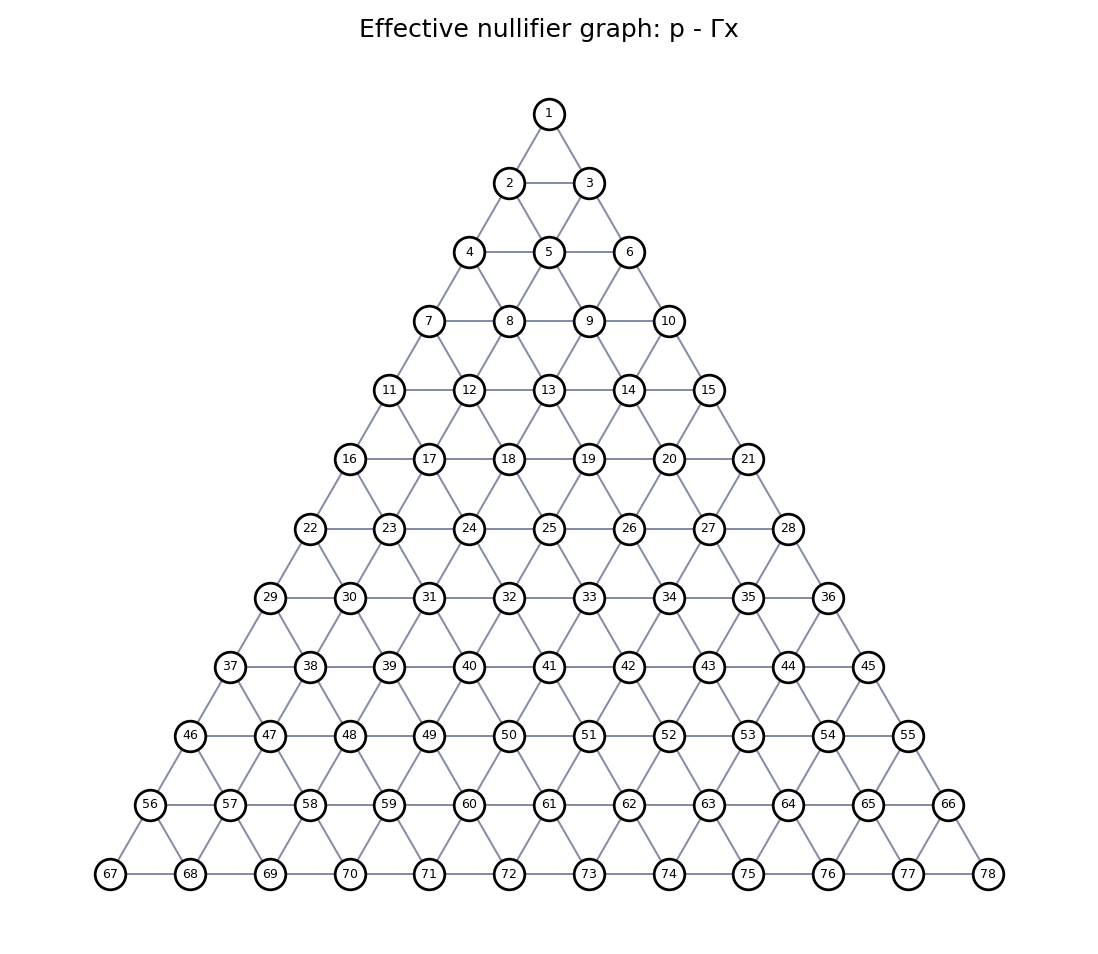

In [8]:
# Effective nullifier graph from V
V_xx = V[:m, :m]
V_xp = V[:m, m:]
V_px = V[m:, :m]
V_pp = V[m:, m:]

# nullfier 1 -> delta1 = p - Gamma1 x 꼴인 경우
Gamma1 = V_px @ np.linalg.pinv(V_xx)
Vd1 = V_pp - Gamma1 @ V_xp - V_px @ Gamma1.T + Gamma1 @ V_xx @ Gamma1.T


# nullfier 2 -> delta2 = x - Gamma2 p 꼴인 경우
Gamma2 = V_xp @ np.linalg.pinv(V_pp)
Vd2 = V_xx - Gamma2 @ V_px - V_xp @ Gamma2.T + Gamma2 @ V_pp @ Gamma2.T

# choose better nullifier
if np.trace(Vd1) <= np.trace(Vd2):
    Gamma_eff = Gamma1
    V_delta = Vd1
    nullifier_type = "p - Γx"
else:
    Gamma_eff = Gamma2
    V_delta = Vd2
    nullifier_type = "x - Γp"

nullifier_var = np.diag(V_delta)




print("chosen:", nullifier_type)
# nullifier variances 출력
print("nullifier variances =", nullifier_var)

# check nullifier variances below vacuum
print("below vacuum:", nullifier_var < 1)

# 해당 nullifer variances로 나온 effective adjacency matrix 출력
print("Adj_eff =\n", Gamma_eff)


# plot the graph using the graph plotting function defined above 
# plot_graph_from_matrix (W=Gamma_eff, node_values=kurtosis같은 노드별 값(기본은 none), title=f"(제목)", pos=pos(기본은 none))
pos = plot_graph_from_matrix(
    Gamma_eff,
    node_values=None,
    title=f"Effective nullifier graph: {nullifier_type}",
    pos= 
    # {
    # 0: (0.0, 0.0),
    # 1: (1.5, 0.0),
    # 2: (2.75, 0.9),
    # 3: (2.75, -0.9),
    # 4: (4.0, 0.0),
    # 5: (5.5, 0.0),
    # }
    triangular_lattice_adjacency(12)[1]
)

## 2. Photon Subtraction on the graph

##### A Matrix for Photon Subtraction

Pi_g projector check: True
A_minus symmetric check: True


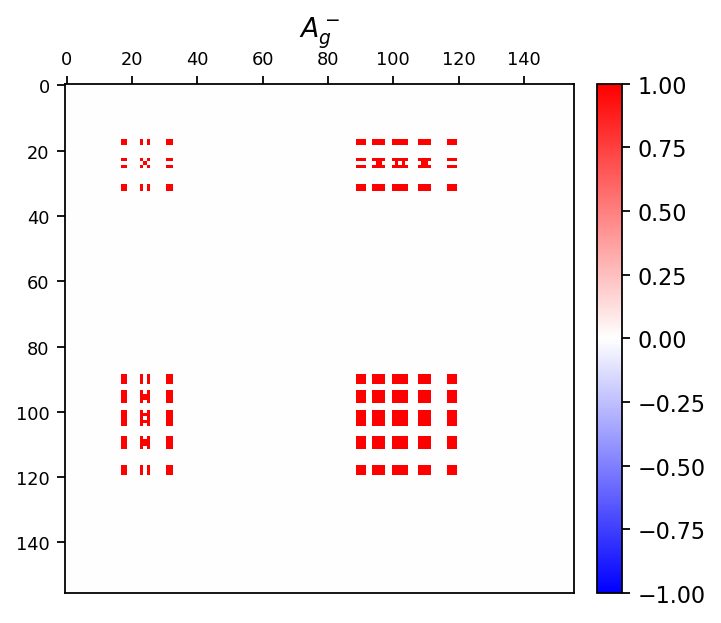

In [9]:
# A_minus matrix
# A_minus = 2 (V - I) Πg (V - I) / Tr[(V - I) Πg]

I_2m = np.eye(2 * m) # 2m x 2m identity matrix, m은 모드 수

denom = np.trace((V - I_2m) @ Pi_g) # 분모 계산, Tr[(V - I) Πg] , 이거의 4배값이 photon subtraction의 성공확률

# print("denom =", denom)
# 예외처리
if np.isclose(denom, 0):
    raise ValueError("denom is close to zero: photon subtraction mode may be vacuum-like.")

A_minus = 2 * (V - I_2m) @ Pi_g @ (V - I_2m) / denom

print("Pi_g projector check:", bool(np.linalg.norm(Pi_g @ Pi_g - Pi_g))<1e-10)
print("A_minus symmetric check:", bool(np.linalg.norm(A_minus - A_minus.T) < 1e-10))
#print("A_minus =\n", A_minus)
#show_mat(A_minus, name="A_minus = ")
draw_mat(A_minus, r"$A_g^-$",tick_step = 20)


v_p = [20.1 40.1 40.1 40.1 60.1 40.1 40.1 60.1 60.1 40.1 40.1 60.1 60.1 60.1
 40.1 40.1 60.1 60.1 60.1 60.1 40.1 40.1 60.1 60.1 60.1 60.1 60.1 40.1
 40.1 60.1 60.1 60.1 60.1 60.1 60.1 40.1 40.1 60.1 60.1 60.1 60.1 60.1
 60.1 60.1 40.1 40.1 60.1 60.1 60.1 60.1 60.1 60.1 60.1 60.1 40.1 40.1
 60.1 60.1 60.1 60.1 60.1 60.1 60.1 60.1 60.1 40.1 20.1 40.1 40.1 40.1
 40.1 40.1 40.1 40.1 40.1 40.1 40.1 20.1]
a_p = [  0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           2.93685756  11.74743025   2.93685756   0.
   0.          11.74743025  14.68428781  14.68428781  11.74743025
   0.           0.           2.93685756  14.68428781 102.57885463
  14.68428781   2.93685756   0.           0.           0.
  11.74743025  14.68428781  14.68428781  11.74743025   0.
   0.           0.           0.           0.           2.93685756
  11.74743025   2.93685756   0.           0.           0.
   0.           0.           0.           0. 

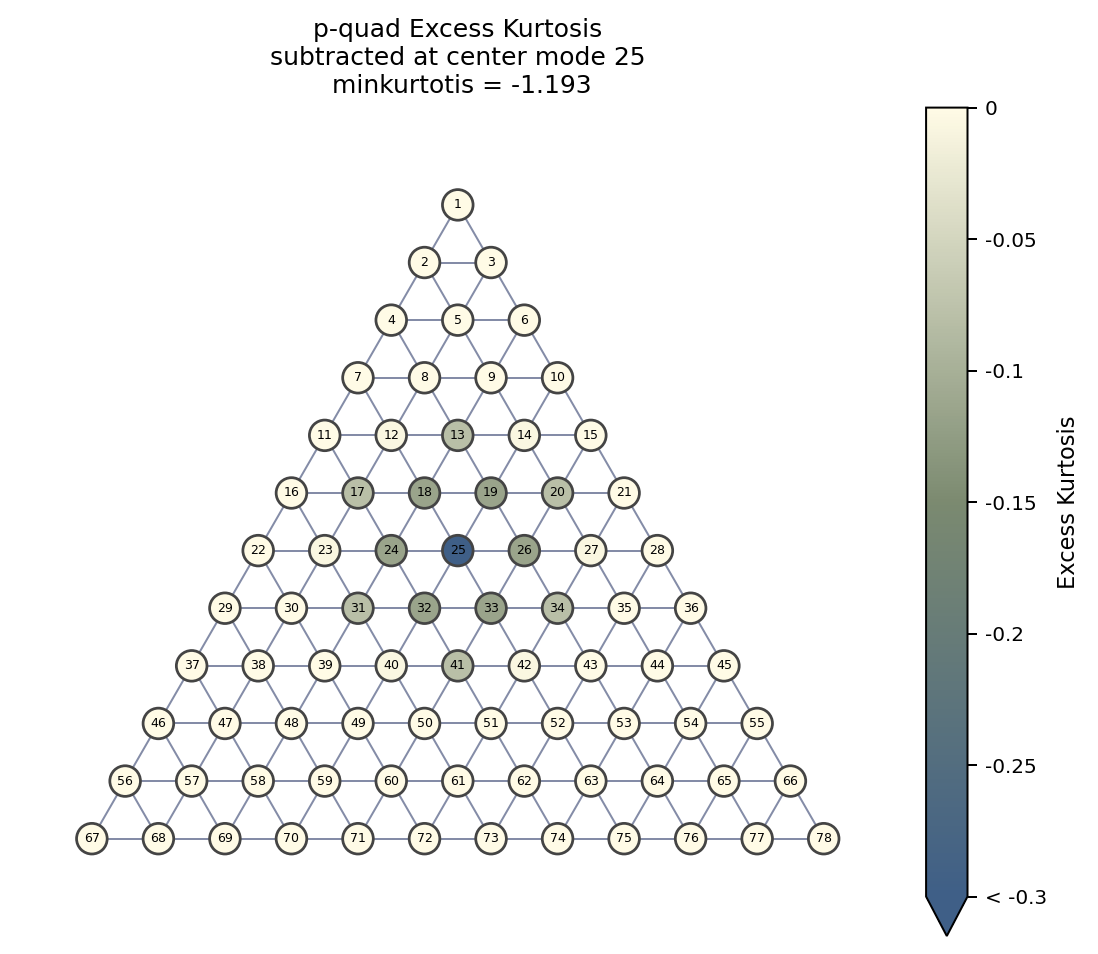

In [10]:
# Node-wise p-quadrature excess kurtosis

p_indices = np.arange(m, 2 * m) # p-quadrature는 phase space 벡터의 뒤쪽 m개 요소에 해당하므로, 인덱스가 m부터 2m-1까지인 부분을 선택

v_p = np.diag(V)[p_indices] # photon subtraction 전의 p-quadrature variance, V 행렬의 뒤쪽 m개 대각 원소에 해당
a_p = np.diag(A_minus)[p_indices] # photon subtraction으로 인한 p-quadrature variance 변화량, A_minus 행렬의 뒤쪽 m개 대각 원소에 해당

K_ex_p = -3 * (a_p ** 2) / ((v_p + a_p) ** 2) # <Q(f)^k>_T를 통해 excess kurtosis p-quadrature 계산, 

print("v_p =", v_p)
print("a_p =", a_p)
print("K_ex_p =", K_ex_p)

# pos = plot_graph_from_matrix(
#     Adj,
#     node_values=K_ex_p,
#     pos=pos,
#     cmap=blue,
#     colorbar_label="Excess Kurtosis",
#     draw_labels=True,
#     title=f"p-quad Excess Kurtosis\nsubtracted at center mode {center_idx + 1}"
# )


pos = plot_graph_from_matrix(
    Adj,
    node_values=K_ex_p,
    pos=pos,
    cmap=blue,
    vmin=-0.3,
    vmax=0.0,
    colorbar_label="Excess Kurtosis",
    colorbar_extend="min",
    draw_labels=True,
    title=f"p-quad Excess Kurtosis\nsubtracted at center mode {center_idx + 1}\n minkurtotis = {np.min(K_ex_p):.3f}"
)

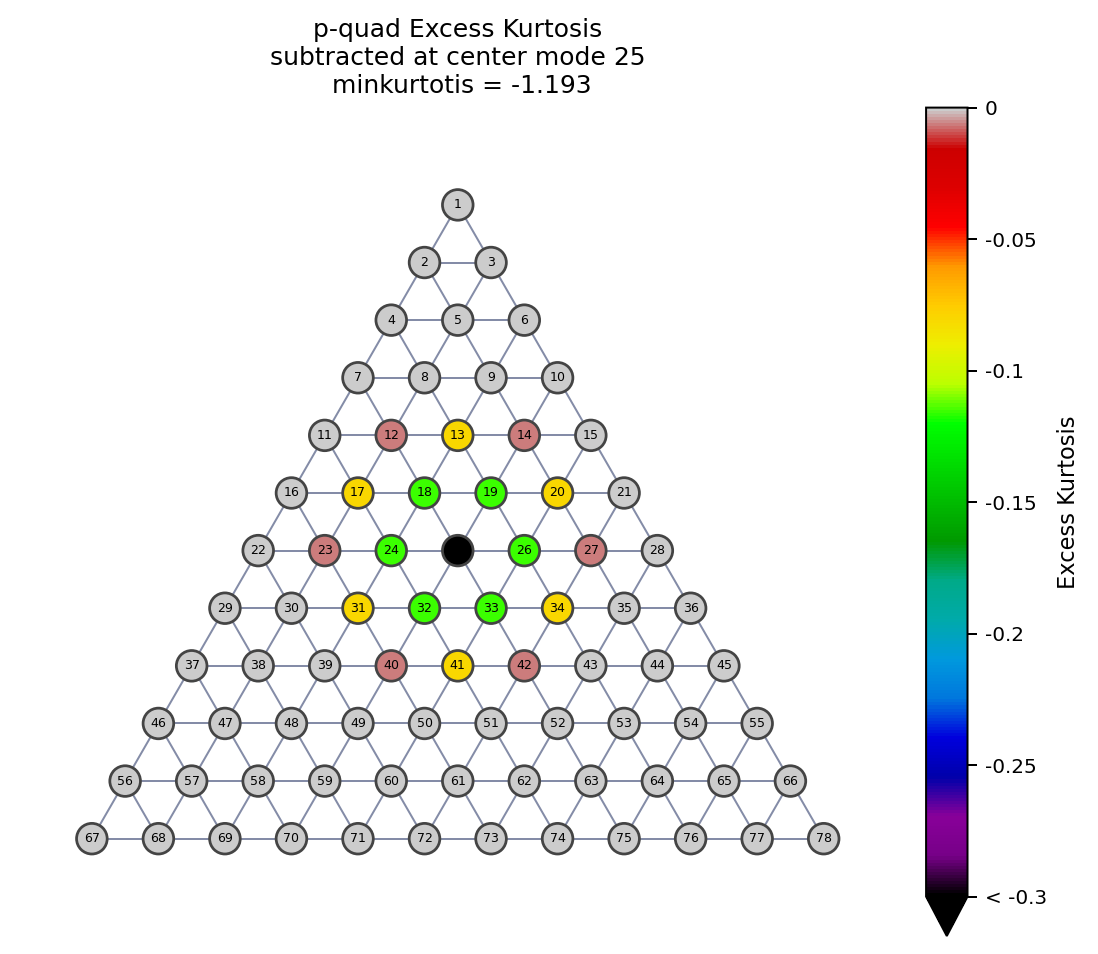

In [25]:

pos = plot_graph_from_matrix(
    Adj,
    node_values=K_ex_p,
    pos=pos,
    cmap="nipy_spectral",
    vmin=-0.3,
    vmax=0.0,
    colorbar_label="Excess Kurtosis",
    colorbar_extend="min",
    draw_labels=True,
    title=f"p-quad Excess Kurtosis\nsubtracted at center mode {center_idx + 1}\n minkurtotis = {np.min(K_ex_p):.3f}"
)